In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk

In [2]:
with open('WESAD/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

In [3]:
# Sampling rates
FS = 700  # Sampling rate for chest sensors from WESAD paper
# Labels: 1 = Baseline, 2 = Stress, 3 = Amusement
labels = data['label']

baseline_indices = np.where(labels == 1)[0]
stress_indices = np.where(labels == 2)[0]

In [4]:
# Extract 30-second snippets from each state
# Take a middle slice of each to avoid transition noise
b_start = baseline_indices[len(baseline_indices)//2]
s_start = stress_indices[len(stress_indices)//2]

# Snippet length 30s
n_samples = FS * 30

In [5]:
# Slice the ECG and GSR
ecg_b = data['signal']['chest']['ECG'][b_start : b_start + n_samples].flatten()
ecg_s = data['signal']['chest']['ECG'][s_start : s_start + n_samples].flatten()

eda_b = data['signal']['chest']['EDA'][b_start : b_start + n_samples].flatten()
eda_s = data['signal']['chest']['EDA'][s_start : s_start + n_samples].flatten()

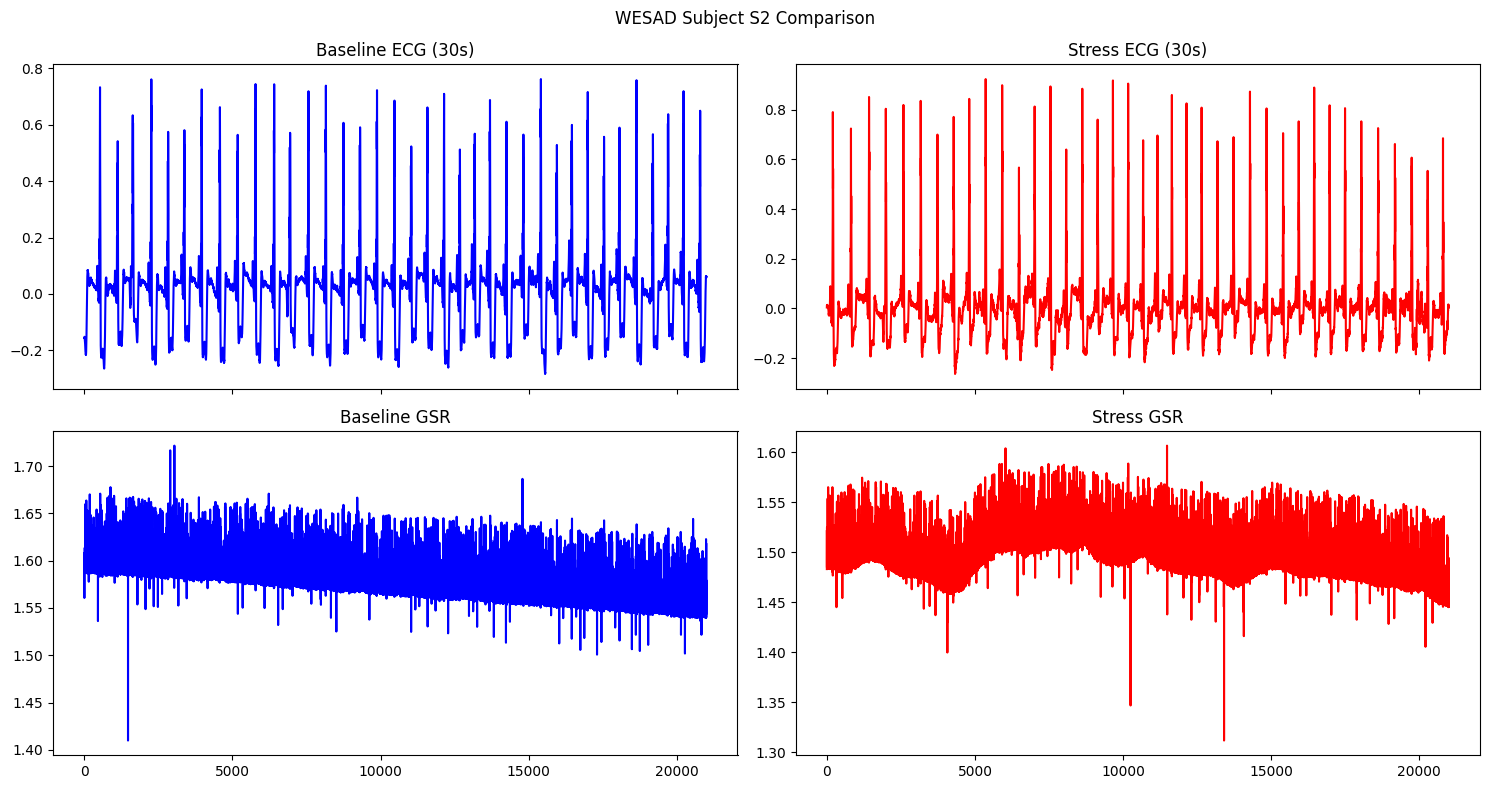

In [23]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8), sharex='col')

# ECG Comparison
ax[0, 0].plot(ecg_b, color='blue')
ax[0, 0].set_title("Baseline ECG (30s)")
ax[0, 1].plot(ecg_s, color='red')
ax[0, 1].set_title("Stress ECG (30s)")

# EDA (GSR) Comparison
ax[1, 0].plot(eda_b, color='blue')
ax[1, 0].set_title("Baseline GSR")
ax[1, 1].plot(eda_s, color='red')
ax[1, 1].set_title("Stress GSR")

plt.suptitle("WESAD Subject S2 Comparison")
plt.tight_layout()
plt.show()

In [ ]:
import warnings

warnings.filterwarnings('ignore', category=pd.errors.ChainedAssignmentError)
warnings.filterwarnings('ignore', category=UserWarning)

In [22]:
# filter noise and finds R-peaks
signals_b, info_b = nk.ecg_process(ecg_b, sampling_rate=FS)
signals_s, info_s = nk.ecg_process(ecg_s, sampling_rate=FS)

# Extract HRV features from the peaks
hrv_baseline = nk.hrv(signals_b, sampling_rate=FS)
hrv_stress = nk.hrv(signals_s, sampling_rate=FS)

rate_b = signals_b["ECG_Rate"].mean()
rate_s = signals_s["ECG_Rate"].mean()

comparison = pd.concat([hrv_baseline, hrv_stress], axis=0)
comparison.index = ['Baseline', 'Stress']

comparison['ECG_Rate_Mean'] = [rate_b, rate_s]

view_cols = ['ECG_Rate_Mean', 'HRV_SDNN', 'HRV_RMSSD']
print(comparison[view_cols])

          ECG_Rate_Mean   HRV_SDNN  HRV_RMSSD
Baseline      74.659171  45.918390  44.476220
Stress        77.711866  41.558584  27.437829


c:\Users\rozsa\VisualStudioCodeProjects\.thesis-env\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\rozsa\VisualStudioCodeProjects\.thesis-env\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


In [21]:
# 1. Process GSR (EDA)
eda_b_signals, _ = nk.eda_process(eda_b, sampling_rate=FS)
eda_s_signals, _ = nk.eda_process(eda_s, sampling_rate=FS)

# 2. Extract features
eda_b_features = nk.eda_analyze(eda_b_signals, sampling_rate=FS)
eda_s_features = nk.eda_analyze(eda_s_signals, sampling_rate=FS)

gsr_comp = pd.concat([eda_b_features, eda_s_features], axis=0)
gsr_comp.index = ['Baseline', 'Stress']

available_cols = [col for col in ['EDA_Mean', 'SCR_Peaks_N', 'SCR_Amplitude_Mean'] if col in gsr_comp.columns]
print(gsr_comp[available_cols])

baseline_rate = 51.0 / 0.5
stress_rate = 15.0 / 0.5

print(f"Baseline SCR Rate: {baseline_rate:.2f} peaks/min")
print(f"Stress SCR Rate: {stress_rate:.2f} peaks/min")


          SCR_Peaks_N
Baseline         51.0
Stress           15.0
Baseline SCR Rate: 102.00 peaks/min
Stress SCR Rate: 30.00 peaks/min


In [15]:
print(eda_s_features.columns.tolist())

['SCR_Peaks_N', 'SCR_Peaks_Amplitude_Mean', 'EDA_Tonic_SD', 'EDA_Sympathetic', 'EDA_SympatheticN', 'EDA_Autocorrelation']


In [18]:
gsr_comp = pd.concat([eda_b_features, eda_s_features], axis=0)
gsr_comp.index = ['Baseline', 'Stress']

# EDA_Sympathetic: A frequency-domain measure of stress (Sympathetic nervous system)
# EDA_Tonic_SD: The variability of the background sweat level
# SCR_Peaks_Amplitude_Mean: How 'strong' the sweat reactions are
view_gsr = ['EDA_Tonic_SD', 'SCR_Peaks_Amplitude_Mean']

print(gsr_comp[view_gsr])

          EDA_Tonic_SD  SCR_Peaks_Amplitude_Mean
Baseline      0.013144                  0.003035
Stress        0.007577                  0.004703
